In [ ]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

In [ ]:
# Data Loading (directly from Kaggle)

# Setting the path to the file you'd like to load
file_path = "online_retail.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ulrikthygepedersen/online-retail-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/tmp/ipykernel_10458/4236570927.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'online-retail-dataset' dataset.


In [ ]:
# Find out the dataset dimensions
df.shape

(541909, 8)

In [ ]:
# Inspect the data
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [ ]:
# explore the customers' countries
# we'll use this more extensively later. for now, just to have an overall view
df['Country'].value_counts()

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
# Convert InvoiceDate from object type to datetime first!
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


We succesfully turned InvoiceDate to datetime64[ns] data type, so we're ready to use this important feature to our analysis!

Now, what about dublicate values?

In [ ]:
print(df.duplicated(keep='first').sum())

5268


In [ ]:
# We're gonna drop these dubplicates and check the outcome
df_clean = df.drop_duplicates()
df_clean.shape

(536641, 8)

In [ ]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,536641.000000,536641,536641.000000,401604.000000
mean,9.620029,2011-07-04 08:57:06.087421952,4.632656,15281.160818
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 10:52:00,1.250000,13939.000000
50%,3.000000,2011-07-19 14:04:00,2.080000,15145.000000
75%,10.000000,2011-10-18 17:05:00,4.130000,16784.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,219.130156,NaN,97.233118,1714.006089


We spot negative values for Quantity and UnitPrice!

At first glance this make no sense.
But, there are two possible scenarios:
1) these numbers are typos and errors
2) they represent order return or refunds

At a real-world scenario I would contact the company
and figure out if they colect refund data or not.

Let's investigate further these features.

<Axes: >

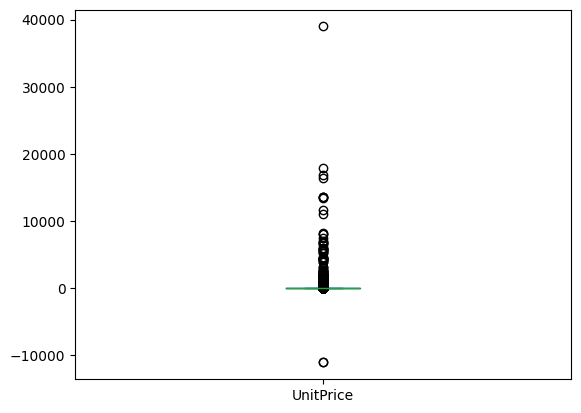

In [ ]:
df_clean['UnitPrice'].plot(kind='box')

In [ ]:
unitprice_q1 = df_clean['UnitPrice'].quantile(0.25)
unitprice_q3 = df_clean['UnitPrice'].quantile(0.75)
unitprice_iqr = unitprice_q3 - unitprice_q1
unitprice_lower_bound = unitprice_q1 - 1.5 * unitprice_iqr
unitprice_upper_bound = unitprice_q3 + 1.5 * unitprice_iqr
unitprice_outliers = (df_clean['UnitPrice'] < unitprice_lower_bound) | (df_clean['UnitPrice'] > unitprice_upper_bound)
df_clean[unitprice_outliers].shape[0]

39450

In [ ]:
# try again with wider bounds
unitprice_lower_bound2 = unitprice_q1 - 3 * unitprice_iqr
unitprice_upper_bound2 = unitprice_q3 + 3 * unitprice_iqr
unitprice_outliers2 = (df_clean['UnitPrice'] < unitprice_lower_bound2) | (df_clean['UnitPrice'] > unitprice_upper_bound2)
df_clean[unitprice_outliers2].shape[0]

12833

We get many "extreme" values even with wider bounds and this is also true for the quantity feature as we explore below.

This is completely normal and of course they can't represent outliers as we have to take under consideration the B2B behavior. They represent high-value customers or bulk orders and they must be treated as business signals.

In [ ]:

(df_clean['UnitPrice'] <= 0).sum() # returns 2512 negative values
df_clean.drop(df_clean[df_clean['UnitPrice'] <= 0].index, inplace=True)
len(df_clean)

/tmp/ipykernel_10458/1203373265.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(df_clean[df_clean['UnitPrice'] <= 0].index, inplace=True)


534129

As the negative values of this attribute are significant less than the positive ones and the negative prices of UnitPrice makes less sense (in contrast with the negative quantity values as we'll see), we will drop these values assuming they are typographic errors but most importantly as they cannot be reliable, without harming the analysis.

Now, lets see what's going on for the Quantity feature.
Here the negative values make a bit more sense based on business logic as they may represent returns of items.

<Axes: >

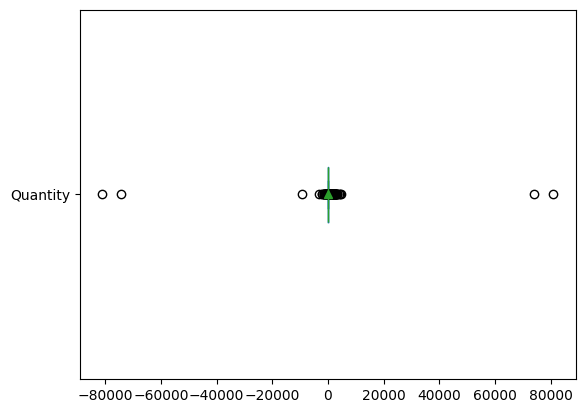

In [ ]:
df_clean['Quantity'].plot(kind='box', vert=False, showmeans=True)

In [ ]:
quantity_q1 = df_clean['Quantity'].quantile(0.25)
quantity_q3 = df_clean['Quantity'].quantile(0.75)
quantity_iqr = quantity_q3 - quantity_q1
quantity_lower_bound = quantity_q1 - 1.5 * quantity_iqr
quantity_upper_bound = quantity_q3 + 1.5 * quantity_iqr
quantity_outliers = (df_clean['Quantity'] < quantity_lower_bound) | (df_clean['Quantity'] > quantity_upper_bound)
df_clean[quantity_outliers].shape[0]

57326

In [ ]:
quantity_lower_bound2 = quantity_q1 - 3 * quantity_iqr
quantity_upper_bound2 = quantity_q3 + 3 * quantity_iqr
quantity_outliers2 = (df_clean['Quantity'] < quantity_lower_bound2) | (df_clean['Quantity'] > quantity_upper_bound2)
df_clean[quantity_outliers2].shape[0]

21048

In [ ]:
# the negatives here will be more, based on the graph
(df_clean['Quantity'] <= 0).sum() # returns 9251
((df_clean['Quantity'] <= 0).sum())/len(df_clean['Quantity'])

np.float64(0.017319786044195318)

This feature's negative values' precentage is also small and drop-able, but if they represent returns we may want to use them as ones. So, instead of dropping them it's prefered to keep them in a seperate artificial sub-dataset to use them later for a "analysis of the returns" that may be also very useful for the company.

In [ ]:
# define the sub-dataset for the returns (negative revenues)
df_returns = df_clean[df_clean['Quantity'] < 0]
df_returns.shape # returns (9251, 8)
df_clean.drop(df_clean[df_clean['Quantity'] < 0].index, inplace=True)
df_clean.shape

/tmp/ipykernel_10458/3635746043.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(df_clean[df_clean['Quantity'] < 0].index, inplace=True)


(524878, 8)

In [ ]:
# define the remaining clean dataset (excluding the negative revenues)
df_clean = df_clean.drop(df_clean[df_clean['Quantity'] < 0].index)
df_clean.shape

(524878, 8)

After dealing with the negative values that spotted in the two above features we explored any missing values. We found the below results:

Description column has 1454 missing values

CustomerID column has 135080 missing values

We'll drop because they cannot be reliably recovered and are not critical for analysis. In contrast, the missing  customer IDs are a very big percentage of our data. Clearly we can't drop them and we still dont know why they exist. Maybe some IDs don't get written into the system. Nearly 1 in 4. So, this is also a useful insight and great importance for the company! Once this is known it can be fixed.For now, letting them to our dataset is not something harmful as long as we don't use those missing values the analysis is untouched.

In [ ]:
# Count the missing values
for col in df.columns:
  if df[col].isnull().sum() != 0:
    print(col, "column has", df[col].isnull().sum(), "missing values")

Description column has 1454 missing values
CustomerID column has 135080 missing values


In [ ]:
print(135080/len(df_clean)) # ~25% of the data

0.2573550425051155


Summurized Final Cleaning Decisions

- Returns (Quantity < 0):
Kept in separate dataset (df_refund) for independent analysis

- UnitPrice ≤ 0:
Removed as invalid transactions

- Missing Description:
Dropped due to low impact and unreliable recovery

- Missing CustomerID:
Kept for transaction analysis, excluded from customer-level analysis


---



After all the above cleaning we have:

1) transformed the date feature to datetime type
2) identified the missing values and dropped the harmful ones
3) identified the countries where the customers come from
4) cleaned the data from dublicates
5) dealed with the outliers and the negative values
6) created a refund dataset (df_refund) for further, seperate analysis



---



After the cleaning we have to dive into feature engineering and make some new features that will be very usefull for the upcomming business analysis with SQL.

In [ ]:
# Feature Engineering
df_clean["UnitPriceInEuros"] = df_clean["UnitPrice"] * 1.15 # based on the rate of 31/3/2025, 15:00 Athens
df_clean["TotalUnitPriceInEuros"] = df_clean["Quantity"] * df_clean["UnitPriceInEuros"]

In [ ]:
df_clean.describe() # again, with the new features

,Quantity,InvoiceDate,UnitPrice,CustomerID,UnitPriceInEuros,TotalUnitPriceInEuros
count,524878.000000,524878,524878.000000,392692.000000,524878.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573,15287.843865,4.510958,23.316709
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001150,0.001150
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,1.437500,4.485000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,2.392000,11.408000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,4.749500,20.355000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,15572.529500,193740.040000
std,156.280031,NaN,36.093028,1713.539549,41.506982,312.447601


From the above descriptive table we can see the new value ranges of the constracted features. We now have an estimation of the amounts of prices. But, it would be better to evaluate and group the orders based no these.

In [ ]:
df_clean['TotalUnitRevenue'] = pd.cut(df_clean['TotalUnitPriceInEuros'], bins=[0, 18, 65, 100, np.inf], labels=['Low Revenue', 'Mid Revenue', 'High Revenue', 'Very High Revenue'])

<Axes: xlabel='TotalUnitRevenue', ylabel='count'>

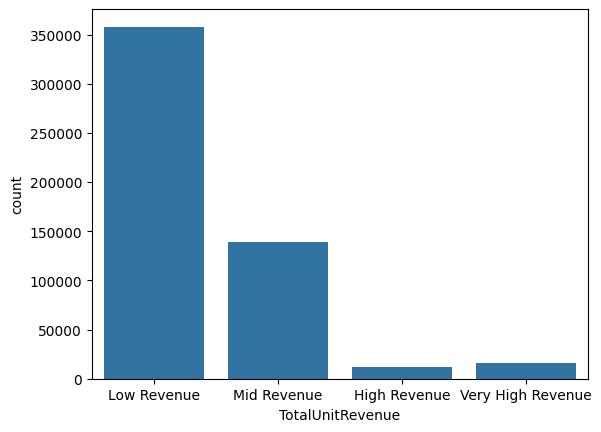

In [ ]:
sns.countplot(x=df_clean['TotalUnitRevenue'])

This manual segmentation was made approximately based on the descritive ranges. We can now use this more detailed graph as a new base for a better and more balanced grouping.

In [ ]:
df_clean['TotalUnitRevenue'] = pd.cut(df_clean['TotalUnitPriceInEuros'], bins=[0, 15, 30, 120, np.inf], labels=['Low Revenue', 'Mid Revenue', 'High Revenue', 'Very High Revenue'])

<Axes: xlabel='TotalUnitRevenue', ylabel='count'>

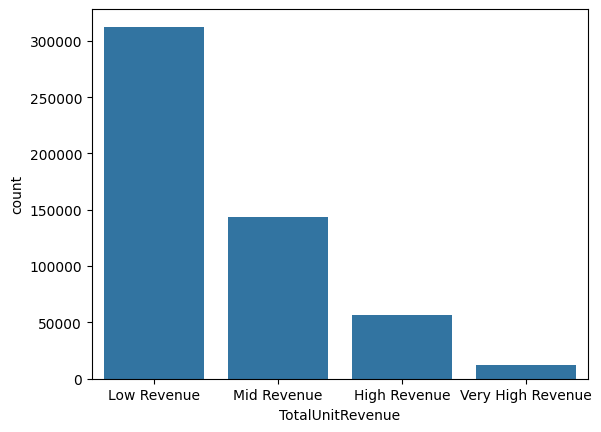

In [ ]:
sns.countplot(x=df_clean['TotalUnitRevenue'])

Now, that we have completed the first part of the analyis (mostly cleaning the data and basic feature engineering) it is time to save our new clean data and move to SQL for the real business analysis.

In [ ]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,UnitPriceInEuros,TotalUnitPriceInEuros,TotalUnitRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2.9325,17.595,Mid Revenue
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,3.8985,23.391,Mid Revenue
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,3.1625,25.300,Mid Revenue
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,3.8985,23.391,Mid Revenue
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,3.8985,23.391,Mid Revenue


In [ ]:
# Save the dataset in a .csv form to load it on SQLite
df_clean.to_csv(
    'data.csv',
    index=False,
    sep=',',
    encoding='utf-8',      # UTF-8 encoding
    quoting=1,             # Quote all fields (prevents issues)
    doublequote=True       # Escape quotes properly
)

df_returns.to_csv(
    'data_refunds.csv',
    index=False,
    sep=',',
    encoding='utf-8',
    quoting=1,
    doublequote=True
)